In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
df = pd.read_csv("student_academic_performance.csv")

df.head()

,Student ID,Gender,Race/Ethnicity,Parental Education,Lunch Type,Test Preparation,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score,School Type,Internet Access
0,1,female,group B,some college,standard,False,12.4,5.4,62.0,76.0,65.0,public,True
1,2,male,group D,high school,standard,False,18.3,5.1,74.0,73.0,76.0,public,NaN
2,3,male,group B,bachelor degree,free/reduced,True,11.8,7.8,71.0,83.0,91.0,public,False
3,4,male,group E,high school,standard,False,NaN,7.3,83.0,73.0,52.0,public,True
4,5,female,group C,bachelor degree,standard,True,12.9,6.3,41.0,NaN,81.0,public,True


In [3]:
df.shape

(7000, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Student ID            7000 non-null   int64  
 1   Gender                7000 non-null   object 
 2   Race/Ethnicity        7000 non-null   object 
 3   Parental Education    6300 non-null   object 
 4   Lunch Type            6790 non-null   object 
 5   Test Preparation      7000 non-null   bool   
 6   Study Time per Week   6370 non-null   float64
 7   Daily Sleep Duration  6440 non-null   float64
 8   Math Score            7000 non-null   float64
 9   Reading Score         6510 non-null   float64
 10  Writing Score         6650 non-null   float64
 11  School Type           7000 non-null   object 
 12  Internet Access       6720 non-null   object 
dtypes: bool(1), float64(5), int64(1), object(6)
memory usage: 663.2+ KB


In [5]:
df.describe()

,Student ID,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score
count,7000.000000,6370.000000,6440.000000,7000.000000,6510.000000,6650.000000
mean,3500.500000,9.662653,7.193587,69.476571,71.134101,70.460451
std,2020.870275,4.681971,1.316991,14.782909,13.818268,13.699283
min,1.000000,0.000000,3.000000,3.000000,21.000000,14.000000
25%,1750.750000,6.400000,6.300000,59.000000,62.000000,61.000000
50%,3500.500000,9.600000,7.200000,70.000000,71.000000,71.000000
75%,5250.250000,12.800000,8.100000,80.000000,81.000000,80.000000
max,7000.000000,26.100000,11.000000,100.000000,100.000000,100.000000


In [6]:
df.isnull().sum()

Student ID                0
Gender                    0
Race/Ethnicity            0
Parental Education      700
Lunch Type              210
Test Preparation          0
Study Time per Week     630
Daily Sleep Duration    560
Math Score                0
Reading Score           490
Writing Score           350
School Type               0
Internet Access         280
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['Average Score'] = (
    df['Math Score'] +
    df['Reading Score'] +
    df['Writing Score']
) / 3

df.head()

,Student ID,Gender,Race/Ethnicity,Parental Education,Lunch Type,Test Preparation,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score,School Type,Internet Access,Average Score
0,1,female,group B,some college,standard,False,12.400000,5.4,62.0,76.000000,65.0,public,True,67.666667
1,2,male,group D,high school,standard,False,18.300000,5.1,74.0,73.000000,76.0,public,False,74.333333
2,3,male,group B,bachelor degree,free/reduced,True,11.800000,7.8,71.0,83.000000,91.0,public,False,81.666667
3,4,male,group E,high school,standard,False,9.662653,7.3,83.0,73.000000,52.0,public,True,69.333333
4,5,female,group C,bachelor degree,standard,True,12.900000,6.3,41.0,71.134101,81.0,public,True,64.378034


In [12]:
df['Result'] = np.where(df['Average Score'] >= 40, 'Pass', 'Fail')

df.head()

,Student ID,Gender,Race/Ethnicity,Parental Education,Lunch Type,Test Preparation,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score,School Type,Internet Access,Average Score,Result
0,1,female,group B,some college,standard,False,12.400000,5.4,62.0,76.000000,65.0,public,True,67.666667,Pass
1,2,male,group D,high school,standard,False,18.300000,5.1,74.0,73.000000,76.0,public,False,74.333333,Pass
2,3,male,group B,bachelor degree,free/reduced,True,11.800000,7.8,71.0,83.000000,91.0,public,False,81.666667,Pass
3,4,male,group E,high school,standard,False,9.662653,7.3,83.0,73.000000,52.0,public,True,69.333333,Pass
4,5,female,group C,bachelor degree,standard,True,12.900000,6.3,41.0,71.134101,81.0,public,True,64.378034,Pass


In [13]:
pass_fail = df['Result'].value_counts()

pass_fail

Result
Pass    6650
Fail     350
Name: count, dtype: int64

In [14]:
pass_rate = (pass_fail['Pass'] / len(df)) * 100
fail_rate = (pass_fail['Fail'] / len(df)) * 100

print("Pass Rate:", pass_rate)
print("Fail Rate:", fail_rate)

Pass Rate: 95.0
Fail Rate: 5.0


In [15]:
subject_scores = df[['Math Score','Reading Score','Writing Score']].mean()

subject_scores

Math Score       69.476571
Reading Score    71.134101
Writing Score    70.460451
dtype: float64

In [16]:
df[['Study Time per Week','Average Score']].corr()

,Study Time per Week,Average Score
Study Time per Week,1.000000,-0.009988
Average Score,-0.009988,1.000000


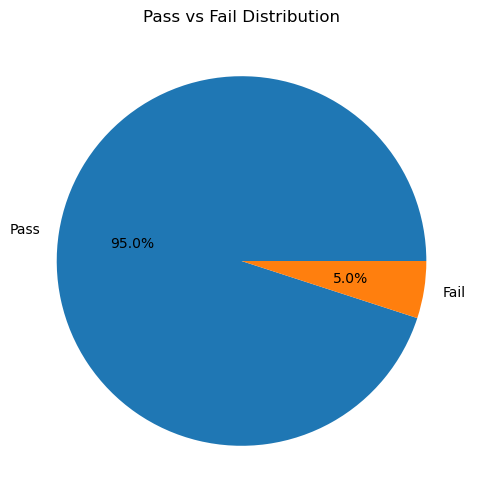

In [17]:
plt.figure(figsize=(6,6))
pass_fail.plot(kind='pie', autopct='%1.1f%%')
plt.title("Pass vs Fail Distribution")
plt.ylabel("")
plt.show()

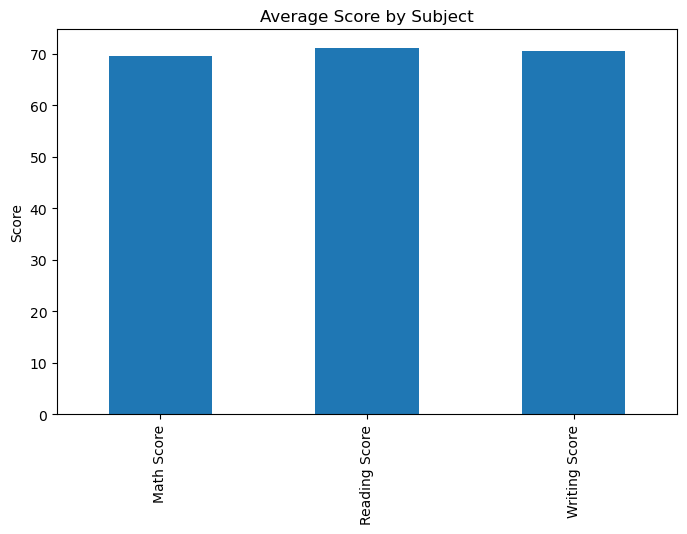

In [18]:
plt.figure(figsize=(8,5))
subject_scores.plot(kind='bar')
plt.title("Average Score by Subject")
plt.ylabel("Score")
plt.show()

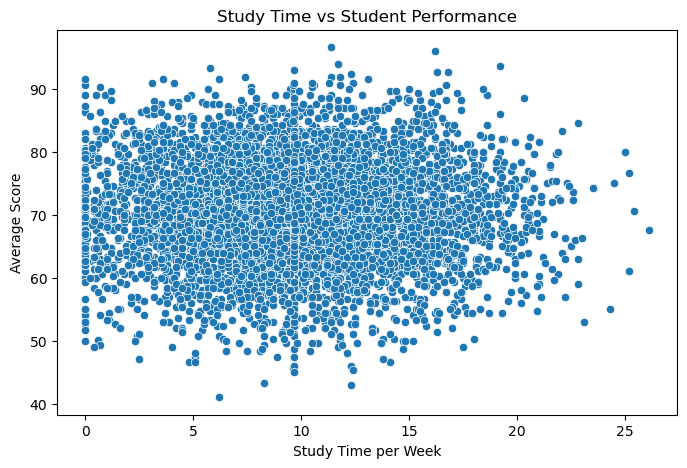

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Study Time per Week', y='Average Score', data=df)
plt.title("Study Time vs Student Performance")
plt.show()

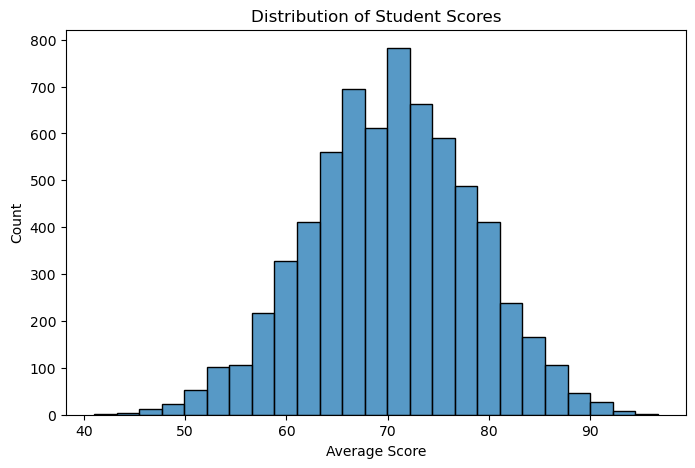

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df['Average Score'], bins=25)
plt.title("Distribution of Student Scores")
plt.show()

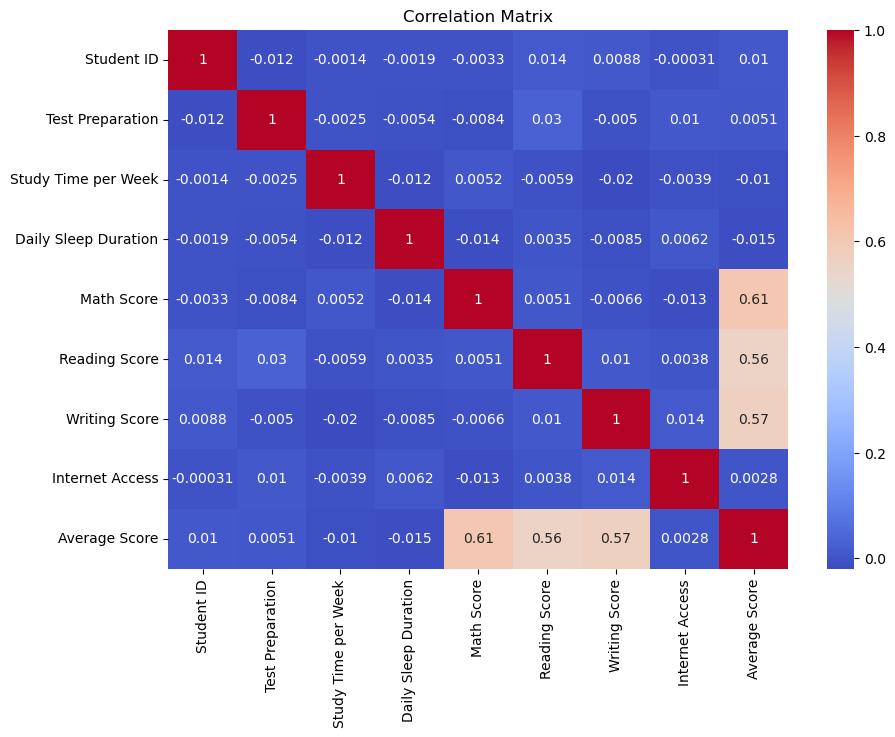

In [22]:
plt.figure(figsize=(10,7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Key Findings:

-Most students successfully pass the exams.
-Reading and writing scores are slightly higher than math scores.
-Study time has a positive correlation with academic performance.
-Students studying more hours per week tend to achieve better scores.

Education Insights:
-Encourage structured study schedules.
-Provide additional support for students struggling in mathematics.
-Promote study resources for students with limited internet access.
-Introduce mentorship programs for low-performing students.

In [23]:
df.to_csv("cleaned_student_performance.csv", index=False)